In [2]:
import numpy as np
import matplotlib.pyplot as plt
import os, struct

In [3]:
from utils.enzo import IA2, IA2Data, get_redshift
from utils.units import CGS
from utils.gravity import get_gravpot
from utils.visualize import set_style, DefaultStyle, get_cbar
from utils.clusters import calc_avgvelocity

In [4]:
Path = '/media/yange/MyDrive/2024PhDData/EnzoIA2/E14-R/'
ia2 = IA2Data(Path)

snapshot = 10
c = 5

In [5]:
# Load units
Delta = 200
params_fName = os.path.join(ia2.Path,f'cluster_{Delta}.txt')
r_Delta, M_Delta, rho_Delta, c_s, t_s = np.loadtxt(params_fName,skiprows=1,max_rows=1,delimiter=',')

rho_cs = np.loadtxt(os.path.join(ia2.Path,f'rho_c.txt'),skiprows=1)
idx, = np.where(rho_cs==15)[0]
rho_c = rho_cs[idx,1]

In [6]:
# Define code-units.

mu = .5

L_0 = r_Delta
v_0 = c_s
rho_0 = rho_c

t_0 = L_0/v_0 # time unit in seconds
B_0 = v_0 * (4*np.pi*rho_0)**.5 # Magnetic field unit in Gauss (G)
p_0 = rho_0*v_0**2 # Pressure unit in dyne/cm^2

K_0 = CGS.mp * v_0**2 / CGS.kB
G_0 = CGS.G / (1/rho_0/t_0**2)

In [7]:
redshift = get_redshift(snapshot)
dL = IA2.dL*(CGS.pc*1e3)/(1+redshift) / L_0 * c

centre = ia2.get_centre(snapshot)
x, y, z = tuple(ia2.get_x(c=c,_shift=_centre,units='cgs')/L_0 for _centre in centre)

In [8]:
rho = ia2.get_val('Density',snapshot,c=c) / rho_c
dm = ia2.get_val('Dark_Matter_Density',snapshot,c=c) / rho_c
temp = ia2.get_val('Temperature',snapshot,c=c) / K_0
vx1 = ia2.get_val('x-velocity',snapshot,c=c) / v_0
vx2 = ia2.get_val('y-velocity',snapshot,c=c) / v_0
vx3 = ia2.get_val('z-velocity',snapshot,c=c) / v_0
Bx1 = ia2.get_val('Bx',snapshot,c=c) / B_0
Bx2 = ia2.get_val('By',snapshot,c=c) / B_0
Bx3 = ia2.get_val('Bz',snapshot,c=c) / B_0

prs = rho*temp/mu

FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = '/media/yange/MyDrive/2024PhDData/EnzoIA2/E14-R/8mdmd001R_v_010', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

## Subtract Average Velocity

In [ ]:
avg_vel = calc_avgvelocity(rho+dm,(vx1,vx2,vx3))
vx1_sh = vx1-avg_vel[0]
vx2_sh = vx2-avg_vel[1]
vx3_sh = vx3-avg_vel[2]

In [11]:
# gravpot_cgs = get_gravpot((dm+rho)*rho_0,(dL*L_0,dL*L_0,dL*L_0),G=CGS.G)
gravpot = get_gravpot((dm+rho),(dL,dL,dL),G=G_0)

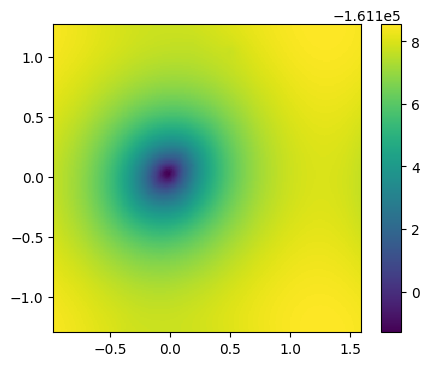

In [12]:
fig, ax = plt.subplots(figsize=DefaultStyle.figkwargs['figsize'])

im = ax.pcolormesh(z,y,gravpot[centre[0]//c])
ax.set_aspect(1)
cbar = get_cbar(im,fig,ax)

In [13]:
var_dict = {
    'rho' : rho,
    'prs' : prs,
    'vx1' : vx1,
    'vx2' : vx2,
    'vx3' : vx3,
    'Bx1' : Bx1,
    'Bx2' : Bx2,
    'Bx3' : Bx3,
    'pot' : gravpot,
}

In [14]:
savePath = Path

In [15]:
save_names = [key+'0.dbl' for key in var_dict.keys()]
n_points = (ia2.dim//c)**3

for i, (key,value) in enumerate(var_dict.items()):
    with open(os.path.join(savePath, f'{key}0.dbl'),'wb') as f_o:   
        f_o.write(struct.pack('<'+'d'*n_points,*(value.T.flatten())))

In [16]:
L = dL * (ia2.dim//c)
L

np.float64(2.5424448565061306)

In [19]:
DIM = 3
shape = (ia2.dim//c,)*DIM
L = dL * (ia2.dim//c)

with open(os.path.join(savePath, 'grid0.out'),'w') as f_o:

    f_o.write("# GEOMETRY:   CARTESIAN\n")

    for d in range(DIM):
        f_o.write(f"{shape[d]}\n")
        for i in range(shape[d]):
            xL = -0.5 + (i-0.5)/(shape[d] - 1.)
            xR = -0.5 + (i+0.5)/(shape[d] - 1.)
            xL *= L
            xR *= L
            # print(xL)
            f_o.write("{:d}   {:12.6e}  {:12.6e}\n".format(i+1, xL, xR));

In [ ]:
c=1
rho = ia2.get_val('Density',snapshot,c=c)
# dm = ia2.get_val('Dark_Matter_Density',snapshot,c=c)
# # temp = ia2.get_val('Temperature',snapshot,c=c)
# vx1 = ia2.get_val('x-velocity',snapshot,c=c)
# vx2 = ia2.get_val('y-velocity',snapshot,c=c)
# vx3 = ia2.get_val('z-velocity',snapshot,c=c)
# # Bx1 = ia2.get_val('Bx',snapshot,c=c)
# # Bx2 = ia2.get_val('By',snapshot,c=c)
# # Bx3 = ia2.get_val('Bz',snapshot,c=c)

In [ ]:
import sys

In [ ]:
sys.getsizeof(rho)/1e9